¡Hola, Ameua!

Mi nombre es Tonatiuh Cruz. Me complace revisar tu proyecto hoy.

Al identificar cualquier error inicialmente, simplemente los destacaré. Te animo a localizar y abordar los problemas de forma independiente como parte de tu preparación para un rol como data-scientist. En un entorno profesional, tu líder de equipo seguiría un enfoque similar. Si encuentras la tarea desafiante, proporcionaré una pista más específica en la próxima iteración.

Encontrarás mis comentarios a continuación - **por favor no los muevas, modifiques o elimines**.

Puedes encontrar mis comentarios en cajas verdes, amarillas o rojas como esta:

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Éxito. Todo está hecho correctamente.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Observaciones. Algunas recomendaciones.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Necesita corrección. El bloque requiere algunas correcciones. El trabajo no puede ser aceptado con comentarios en rojo.
</div>

Puedes responderme utilizando esto:

<div class="alert alert-block alert-info">
<b>Respuesta del estudiante.</b> <a class="tocSkip"></a>
</div>

# INTRODUCCION

Los clientes de la empresa Beta Bank han presentado una alta tasa de desitimiento, que ha incrementado. Teniendo en cuenta que  los banqueros descubrieron que es más barato salvar a los clientes existentes que atraer nuevos.

Necesitamos predecir si un cliente dejará el banco pronto. Con los datos sobre el comportamiento pasado de los clientes y la terminación de contratos con el banco, el objetivo de este proyecto es crear un modelo con el máximo valor F1 posible. Para aprobar la revisión, se busca un valor F1 de al menos 0.59 verificado para el conjunto de prueba. 

1. Preparar correctamente variables numéricas y categóricas.
2. Dividir en train / validation / test.
3. Crear un modelo base sin corregir el desequilibrio.
4. Examinar el equilibrio de clases
5. Aplicar class_weight='balanced'y upsampling 
6. Comparar Logistic Regression y Random Forest.
7. Hacer una sola prueba final sobre test.
8. Conclusiones Finales

# 1. Descargar y preparar los datos

In [35]:
# Importar Librerías 

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils import shuffle
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    f1_score,
    roc_auc_score,
    accuracy_score,
    precision_score,
    recall_score,
   )

In [36]:
# Cargar datos y revisar características

data = pd.read_csv('/datasets/Churn.csv')

print(data.head())
print(data.info())
print(data.shape)

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0     2.0       0.00              1          1               1   
1     1.0   83807.86              1          0               1   
2     8.0  159660.80              3          1               0   
3     1.0       0.00              2          0               0   
4     2.0  125510.82              1          1               1   

   EstimatedSalary  Exited  
0        101348.88       1  
1        112542.58       0  
2        113931.57       1  
3         93826.63       0  
4         790

In [37]:
# Revisar Valores ausentess

print(data.isna().sum())

RowNumber            0
CustomerId           0
Surname              0
CreditScore          0
Geography            0
Gender               0
Age                  0
Tenure             909
Balance              0
NumOfProducts        0
HasCrCard            0
IsActiveMember       0
EstimatedSalary      0
Exited               0
dtype: int64


Evidenciamos valores ausentes en la columna Tenure: período durante el cual ha madurado el depósito a plazo fijo de un cliente (años). 909 registros, los cuales reempplazaremos por la mediana, para no tener problemas en la construcción del modelo como caracteristica predictiva.

In [38]:
data['Tenure'] = data['Tenure'].fillna(data['Tenure'].median())

# Validamos valores ausente
print(data.isna().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [39]:
# Verificar duplicados exactos
print('Duplicados exactos:', data.duplicated().sum())

# Verificar clientes repetidos
print('CustomerId duplicados:', data['CustomerId'].duplicated().sum())

Duplicados exactos: 0
CustomerId duplicados: 0


Se revisan los valores duplicados ya que puede afectar:

El análisis de la distribución de clases.
El entrenamiento del modelo.
La división train/validation/test.
Las métricas F1 y AUC-ROC.
La posibilidad de que el mismo cliente termine en entrenamiento y prueba.

pero no encontramos evidencia de valores duplicados

## Codificación de características
Tenemos variables categóricas:

Geography
Gender

las cuales convertiremos mediante One-Hot Encoding:


In [40]:
data = pd.get_dummies(
    data,
    columns=['Geography', 'Gender'],
    drop_first=True
)

## Eliminar columnas que no aportan información predictiva

RowNumber, CustomerId y Surname son identificadores/datos nominales que no deberían utilizarse directamente como características.

In [41]:
data = data.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1)

In [42]:
# Preparación de caracteristicas y objetivo

target = data['Exited']
features = data.drop('Exited', axis=1)

#validamos tamaño y cantidad de elementos
print(target.shape)
print(features.shape)

(10000,)
(10000, 11)


# 2. Dividir en train / validation / test.

Una división muy buena para este proyecto es:

60 % entrenamiento

20 % validación

20 % prueba


In [43]:
# Datos de entrenamiento y datos temporales para subdivisión
features_train, features_temp, target_train, target_temp = train_test_split(
    features,
    target,
    test_size=0.40,
    random_state=12345,
    stratify=target
)

# Datos de de validación y de prueba
features_valid, features_test, target_valid, target_test = train_test_split(
    features_temp,
    target_temp,
    test_size=0.50,
    random_state=12345,
    stratify=target_temp
)
#  usamos stratify paras mantener aproximadamente la misma proporción de clientes que abandonaron y que no abandonaron en los tres conjuntos. #

# Validamos Tamaño de los data
print('Train:', features_train.shape)
print('Valid:', features_valid.shape)
print('Test:', features_test.shape)

Train: (6000, 11)
Valid: (2000, 11)
Test: (2000, 11)


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo con la carga inicial de los datos, además lo complementas con un análisis de valores nulos que pudieran sesgar nuestros resultados. Haces la tecnica de imputación de valores de manera perfecta. 

Muy bien, dividiste adecuadamente los datos en entrenamiento, validación y prueba. Los conjuntos son muy importantes, el de validación en particular nos es útil para probar los diferentes hiperparámetros antes de hacer el testeo final con el set de prueba.
</div>

## 3. Crear un modelo base sin corregir el desequilibrio

El modelo inicial a entrenar sin corregir el desequilibrio de clases es logistic regression normal. 

La regresión logística es una buena referencia porque:

1. Es un modelo sencillo y fácil de interpretar.
2. Permite establecer una línea base antes de probar modelos más complejos.
3. No incorpora corrección del desequilibrio por defecto.
4. El modelo trata las clases según su distribución original.
5. Nos permite observar directamente el efecto del desbalance.

Se va a buscar la frecuencia de clase y el desequilibrio, lo que puede provocar que el modelo tenga dificultades para identificar correctamente a los clientes que abandonan el banco. Por esta razón, además de accuracy, utilizaremos F1 como métrica principal.

## Escalar las variables numericas para el modelo logistic regression
Conviene escalar las variables numéricas y se aplica para el conjunto de entrenamiento

In [44]:
numeric_features = [
    'CreditScore',
    'Age',
    'Tenure',
    'Balance',
    'NumOfProducts',
    'EstimatedSalary'
]

scaler = StandardScaler()

features_train_scaled = features_train.copy()
features_valid_scaled = features_valid.copy()
features_test_scaled = features_test.copy()

features_train_scaled[numeric_features] = scaler.fit_transform(
    features_train[numeric_features]
)

features_valid_scaled[numeric_features] = scaler.transform(
    features_valid[numeric_features]
)

features_test_scaled[numeric_features] = scaler.transform(
    features_test[numeric_features]
)

## Aplicación del modelos sin corregir equilibrio de Clases

In [45]:


model = LogisticRegression(
    random_state=12345,
    solver='liblinear'
)

model.fit(features_train_scaled, target_train)

predicted_valid = model.predict(features_valid_scaled)

f1 = f1_score(target_valid, predicted_valid)
auc_roc = roc_auc_score(
    target_valid,
    model.predict_proba(features_valid_scaled)[:, 1]
)

print('F1:', f1)
print('AUC-ROC:', auc_roc)

F1: 0.3076923076923077
AUC-ROC: 0.7875052345058627


Los resultados son compatibles con un problema de desbalance de clases, pero necesitamos comprobar la distribución de Exited y revisar precision, recall  para confirmarlo.

Un F1 de 0.308 indica que, utilizando el umbral de clasificación habitual (normalmente 0.5), el modelo está teniendo dificultades para identificar correctamente la clase positiva (Exited = 1).

Un AUC de 0.788 indica que el modelo tiene una capacidad razonable para distinguir entre ambas clases.

## 4. Examinar el equilibrio de clases
Validar las frecuencia de cada clase para identificar el desequilibrio.

Esto es importante, porque un desequilibrio es un problema  que en un modelo puede favorecer la clase mayoritaria y obtener una buena accuracy, pero un F1 pobre para los clientes que realmente abandonan.

 
0    4778
1    1222
Name: Exited, dtype: int64
0    0.796333
1    0.203667
Name: Exited, dtype: float64


<AxesSubplot:>

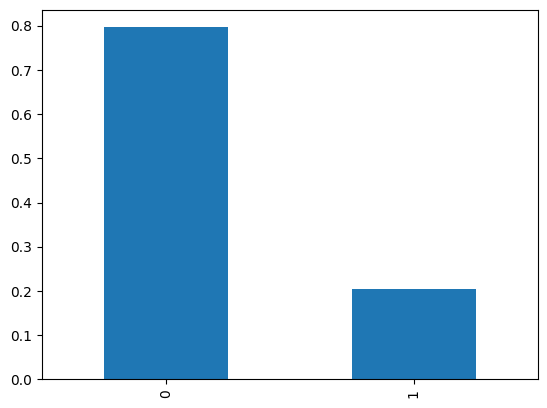

In [46]:
class_frequency = target_train.value_counts(normalize=True)
print(" ")
print(target_train.value_counts())

print(class_frequency)
class_frequency.plot(kind='bar')



Con esto evidenciamos que la clase 0 tiene una frecuencia considerablemente mayor que la clase 1. Esto puede provocar que el modelo tenga dificultades para identificar correctamente a los clientes que abandonan el banco.

## 5. Aplicar class_weight='balanced'y upsampling 

Para el proyecto de Beta Bank,teniendo en cuenta que es un problema de clasificación binaria (Exited = 0/1) y con variables de distintos tipos: numéricas (Age, Balance, CreditScore, etc.) y categóricas (Geography, Gender).

Se toma como modelo Base Regresión Logística es apropiada porque nuestro objetivo es predecir una variable binaria:
Exited = 0 → no abandonó
Exited = 1 → abandonó

Como 2do modelo a aplicar , se toma Random Forest que es interesante para este dataset porque las relaciones entre las características de un cliente y su abandono no necesariamente son lineales.

Por ejemplo, el efecto de: Age, Balance, CreditScore, NumOfProducts, IsActiveMember, puede depender de combinaciones entre variables.

Un modelo lineal podría tener dificultades para representar algunas de esas relaciones. Random Forest construye múltiples árboles de decisión y combina sus predicciones.

Con respecto a los métodos de balance de clases

Inicialmente el metodo peso de clase balanceado , Porque es una forma relativamente sencilla de corregir el desequilibrio sin modificar físicamente el dataset. No estamos creando nuevos clientes ni eliminando registros.

Upsampling aumenta artificialmente la representación de la clase minoritaria, asi tendriamos dos técnicas diferentes.

## Técnica 1 — class_weight='balanced'

a. Model Logistic Regression

b. Random Forest


In [47]:
# a. Model Logistic Regression balanced 

model_balanced = LogisticRegression(
    random_state=12345,
    solver='liblinear',
    class_weight='balanced'
)

model_balanced.fit(features_train_scaled, target_train)

predicted_valid = model_balanced.predict(features_valid_scaled)

f1_balanced = f1_score(target_valid, predicted_valid)

auc_balanced = roc_auc_score(
    target_valid,
    model_balanced.predict_proba(features_valid_scaled)[:, 1]
)

print('F1:', f1_balanced)
print('AUC-ROC:', auc_balanced)

F1: 0.5289982425307558
AUC-ROC: 0.7937004261503596


In [48]:
# b. Model Random Forest balanced

best_model = None
best_f1 = 0
best_depth = 0
best_estimators = 0

for depth in range(2, 16, 2):
    for estimators in [10, 30, 70, 100]:

        model = RandomForestClassifier(
            n_estimators=estimators,
            max_depth=depth,
            random_state=12345,
            class_weight='balanced'
        )

        model.fit(features_train, target_train)

        predicted_valid = model.predict(features_valid)

        f1 = f1_score(target_valid, predicted_valid)

        if f1 > best_f1:
            best_f1 = f1
            best_model = model
            best_depth = depth
            best_estimators = estimators

rf_balanced = RandomForestClassifier(
    n_estimators=best_estimators,
    max_depth=best_depth,
    class_weight='balanced',
    random_state=12345
)

rf_balanced.fit(features_train, target_train)

# Predicciones de clase
predicted_valid = rf_balanced.predict(features_valid)

# Probabilidades de la clase 1
probabilities_valid = rf_balanced.predict_proba(features_valid)[:, 1]

# Métricas
auc_balanced_rf = roc_auc_score(target_valid, probabilities_valid)

print('Mejor F1:', best_f1)
print('AUC-ROC:', auc_balanced_rf)
print('Mejor max_depth:', best_depth)
print('Mejor n_estimators:', best_estimators)

Mejor F1: 0.649164677804296
AUC-ROC: 0.8699225293132329
Mejor max_depth: 10
Mejor n_estimators: 30


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Excelente forma de realizar un ciclo for para hacer la prueba con diferentes hiperparametros. Además, es muy util hacer el análisis con diferentes técnicas de balanceo para fortelecer nuestros resultados.

## Técnica 2 — Upsampling
a. Model Logistic Regression

b. Random Forest


In [49]:
# Aumento de la clase minoritaria

features_zeros = features_train_scaled[target_train == 0]
features_ones = features_train_scaled[target_train == 1]

target_zeros = target_train[target_train == 0]
target_ones = target_train[target_train == 1]

In [50]:
# Calculo de cantidad a aumentar clase minoritaria

repeat = len(target_zeros) // len(target_ones)

In [51]:
# Creación de conjunto aumentado

features_upsampled = pd.concat(
    [features_zeros] + [features_ones] * repeat
)

target_upsampled = pd.concat(
    [target_zeros] + [target_ones] * repeat
)

In [52]:
# Mezcla de data

features_upsampled, target_upsampled = shuffle(
    features_upsampled,
    target_upsampled,
    random_state=12345
)

In [53]:
# a. Model logistc regression upsampled

model_upsampled = LogisticRegression(
    random_state=12345,
    solver='liblinear'
)

model_upsampled.fit(features_upsampled, target_upsampled)

predicted_valid = model_upsampled.predict(features_valid_scaled)

f1_upsampled = f1_score(target_valid, predicted_valid)

auc_upsampled = roc_auc_score(
    target_valid,
    model_upsampled.predict_proba(features_valid_scaled)[:, 1]
)

print('F1:', f1_upsampled)
print('AUC-ROC:', auc_upsampled)

F1: 0.5246231155778894
AUC-ROC: 0.7927258843235787


In [54]:

# b. Random Forest upsampled

best_model_upsampled = None
best_f1_upsampled = 0
best_depth_upsampled = 0
best_estimators_upsampled = 0

for depth in range(2, 16, 2):
    for estimators in [10, 30, 70, 100]:

        model_random_upsampled = RandomForestClassifier(
            n_estimators=estimators,
            max_depth=depth,
            random_state=12345
        )

        model_random_upsampled.fit(
            features_upsampled,
            target_upsampled
        )

        predicted_valid = model_random_upsampled.predict(features_valid)

        f1 = f1_score(target_valid, predicted_valid)

        if f1 > best_f1_upsampled:
            best_f1_upsampled = f1
            best_model_upsampled = model_random_upsampled
            best_depth_upsampled = depth
            best_estimators_upsampled = estimators


# Usamos directamente el mejor modelo encontrado
predicted_valid = best_model_upsampled.predict(features_valid)

# Probabilidades de la clase 1
probabilities_valid = best_model_upsampled.predict_proba(
    features_valid
)[:, 1]

# AUC-ROC
auc_upsampled_rf = roc_auc_score(
    target_valid,
    probabilities_valid
)

print('AUC-ROC:', auc_upsampled_rf)
print('Mejor F1:', best_f1_upsampled)
print('Mejor max_depth:', best_depth_upsampled)
print('Mejor n_estimators:', best_estimators_upsampled)


AUC-ROC: 0.5187610848359444
Mejor F1: 0.3655130540376442
Mejor max_depth: 4
Mejor n_estimators: 10


## 6. Comparaciónde Modelo Logistic Regression vs Random Forest con ambas técnicas


| Modelo / técnica                                |         F1 |    AUC-ROC | Parámetros     |
| ----------------------------------------------- | ---------: | ---------: | -------------- |
| Logistic Regression sin balancear               | **0.3077** | **0.7875** | Baseline       |
| Logistic Regression + `class_weight='balanced'` | **0.5290** | **0.7937** | —              |
| Logistic Regression + upsampling                | **0.5246** | **0.7927** | —              |
| Random Forest + `class_weight='balanced'`       | **0.6492** | **0.8699** | depth=10, n=30 |
| Random Forest + upsampling                      | **0.3655** | **0.5188** | depth=4, n=10  |


Análisis de los resultados

El modelo inicial de Regresión Logística, entrenado sin corregir el desequilibrio de clases, obtuvo un F1 de 0.3077 y un AUC-ROC de 0.7875. Aunque el AUC-ROC muestra una capacidad de discriminación razonable, el F1 relativamente bajo indica dificultades para identificar correctamente la clase minoritaria.

Al aplicar class_weight='balanced', el F1 de la Regresión Logística aumentó hasta 0.5290, mientras que el AUC-ROC alcanzó 0.7937. El modelo con upsampling obtuvo resultados similares, con un F1 de 0.5246 y un AUC-ROC de 0.7927. Esto muestra que ambas técnicas ayudaron a mejorar la identificación de la clase minoritaria.

El mejor resultado de las pruebas fue obtenido por Random Forest con class_weight='balanced', alcanzando un F1 de 0.6492 y un AUC-ROC de 0.8699, utilizando max_depth=10 y n_estimators=30. Este resultado supera a los modelos de Regresión Logística evaluados y muestra una mejor capacidad de clasificación en el conjunto de validación.

Por otro lado, Random Forest con upsampling obtuvo un F1 de 0.3655 y un AUC-ROC de 0.5188, resultados considerablemente inferiores.

En conclusión, dentro de los modelos y técnicas evaluados hasta este punto, Random Forest utilizando class_weight='balanced' presentó los mejores resultados en validación. Este modelo será candidato para la evaluación final sobre el conjunto de prueba.

## 7. Validación Final con los datos de Prueba

Una vez elegidos:

modelo
hiperparámetros
técnica de balanceo
umbral

Se valida con el conjunto de prueba para seguir tomando decisiones.

In [58]:
# Optimizacion del F1

probabilities_valid = best_model.predict_proba(features_valid)[:, 1]

best_threshold = 0.5
best_f1_threshold = 0

for threshold in np.arange(0.1, 0.6, 0.02):

    predicted_valid = probabilities_valid > threshold

    f1 = f1_score(target_valid, predicted_valid)

    if f1 > best_f1_threshold:
        best_f1_threshold = f1
        best_threshold = threshold

print('Mejor threshold:', best_threshold)
print('Mejor F1:', best_f1_threshold)

Mejor threshold: 0.4800000000000001
Mejor F1: 0.6564705882352941


In [59]:

final_probabilities = best_model.predict_proba(features_test)[:, 1]

final_predictions = (
    final_probabilities > best_threshold
).astype(int)

final_f1 = f1_score(target_test, final_predictions)

final_auc = roc_auc_score(
    target_test,
    final_probabilities
)

print('F1 final:', final_f1)
print('AUC-ROC final:', final_auc)

F1 final: 0.5961995249406176
AUC-ROC final: 0.8483552890332551


In [60]:
# Métricas 
print('Precision:', precision_score(target_test, final_predictions))
print('Recall:', recall_score(target_test, final_predictions))
print('Accuracy:', accuracy_score(target_test, final_predictions))


Precision: 0.5770114942528736
Recall: 0.6167076167076168
Accuracy: 0.83


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a>

Gran trabajo corriendo los modelos y haciendo la identificación de la mejor exactitud. Además, los complementas con la prueba con diferentes hiperparametros para comparar el valor de AUC-ROC. Esto lo puedes terminar de complementar con el gráfico de los resultados AUC-ROC. 

## 8. Conclusiones Finales

Durante el proyecto se desarrolló un modelo de clasificación para predecir la probabilidad de abandono de los clientes de Beta Bank. Inicialmente se entrenó un modelo de Regresión Logística sin corregir el desequilibrio de clases, que obtuvo un F1 de 0.3077 y un AUC-ROC de 0.7875. Este resultado mostró que, aunque el modelo tenía cierta capacidad para distinguir entre las clases, presentaba dificultades para identificar correctamente a los clientes de la clase minoritaria (Exited = 1).

Posteriormente, se evaluaron diferentes estrategias para tratar el desequilibrio de clases, incluyendo class_weight='balanced' y upsampling, utilizando Regresión Logística y Random Forest. Entre las configuraciones evaluadas, Random Forest con class_weight='balanced' obtuvo el mejor desempeño en el conjunto de validación, alcanzando un F1 de 0.6492 y un AUC-ROC de 0.8699, con max_depth=10 y n_estimators=30.

Después de seleccionar el modelo, se realizó una optimización del umbral de clasificación. El mejor umbral encontrado fue 0.48, con un F1 de 0.6565 en el conjunto de validación. Esto permitió mejorar ligeramente el F1 respecto al resultado obtenido utilizando el umbral convencional.

Finalmente, el modelo optimizado se evaluó utilizando datos de prueba que no habían sido utilizados durante el entrenamiento ni durante la selección de los hiperparámetros. Los resultados fueron:

F1: 0.5962
AUC-ROC: 0.8484
Precision: 0.5770
Recall: 0.6167
Accuracy: 0.83

El F1 final de 0.5962 supera el objetivo mínimo establecido de 0.59, por lo que el modelo cumple con el criterio principal de evaluación del proyecto.

El recall de 0.6167 indica que el modelo identifica aproximadamente el 61.7% de los clientes que realmente abandonaron el banco. La precision de 0.5770 indica que aproximadamente el 57.7% de los clientes clasificados por el modelo como posibles abandonos pertenecen realmente a la clase de abandono.

Por otra parte, el AUC-ROC de 0.8484 muestra que el modelo mantiene una buena capacidad para distinguir entre clientes que abandonan y clientes que permanecen en el banco. La diferencia entre el AUC-ROC y el F1 también muestra la importancia de seleccionar adecuadamente el umbral de clasificación cuando existe un desequilibrio entre las clases.

En conclusión, Random Forest con class_weight='balanced', optimizado mediante selección de hiperparámetros y ajuste del umbral de clasificación a 0.48, fue la configuración seleccionada para la evaluación final. El modelo alcanzó un F1 de 0.5962 sobre datos de prueba y cumplió el objetivo establecido para el proyecto.